>## Assignment: Positions of a quasar

You measure the position of a quasar $N$ times with the *same* telescope i.e. errors are homoscedastic (same for all measurements). Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the errors are $\sigma=0.2$

### Part 1

- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.
- Plot each of the individual likelihoods separately.  Also plot their product (i.e. the likelihood of the dataset $\{x_i\}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`). 
- Compare it with the MLE estimator derived above.

### Part 2

Check if the Fisher matrix error estimate makes sense
- do a rough $2^\mathrm{nd}$ order differentiation of our log-likelihood function with `np.diff`, 
- divide through by our $\Delta \theta^2$ to get the correct normalization, 
- multiply by $-1$, 
- then take the square root.
- Compare with the Fisher matrix error derived above.
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees).

### Part 3

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurement has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$

- Generalize your code from above to this case

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Maximum Likelihood Estimate of mu: 0.9660
Analytical MLE of mu (mean of data): 0.9642


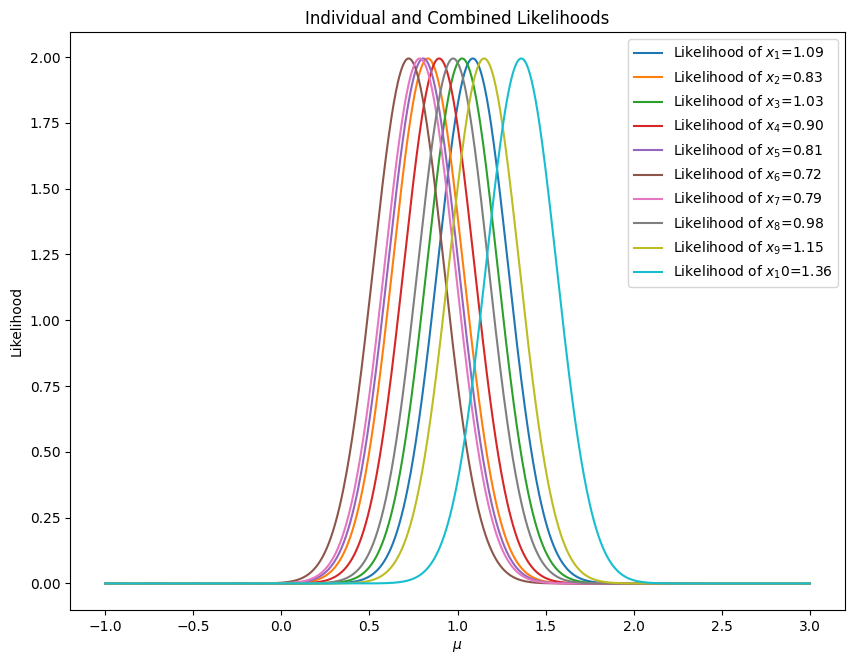

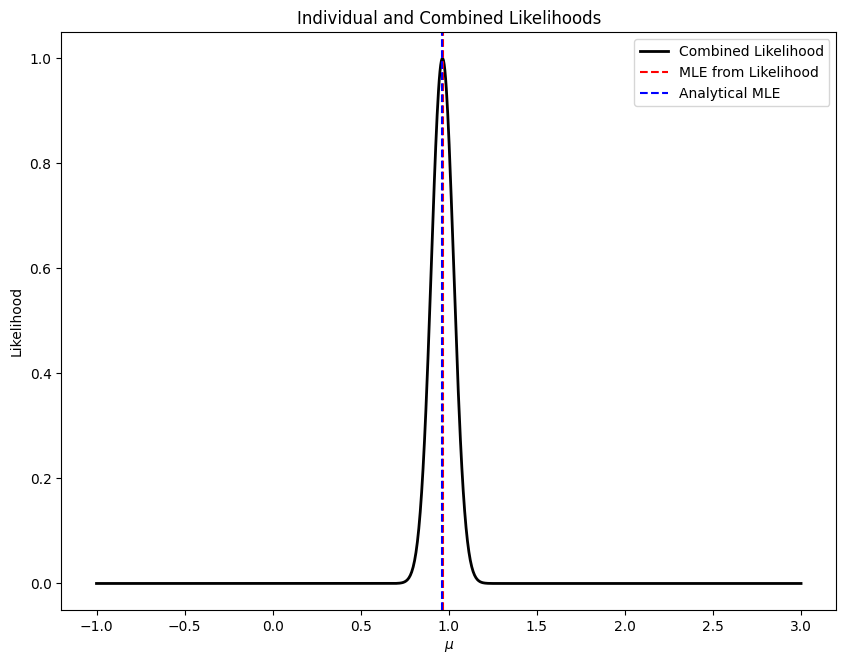

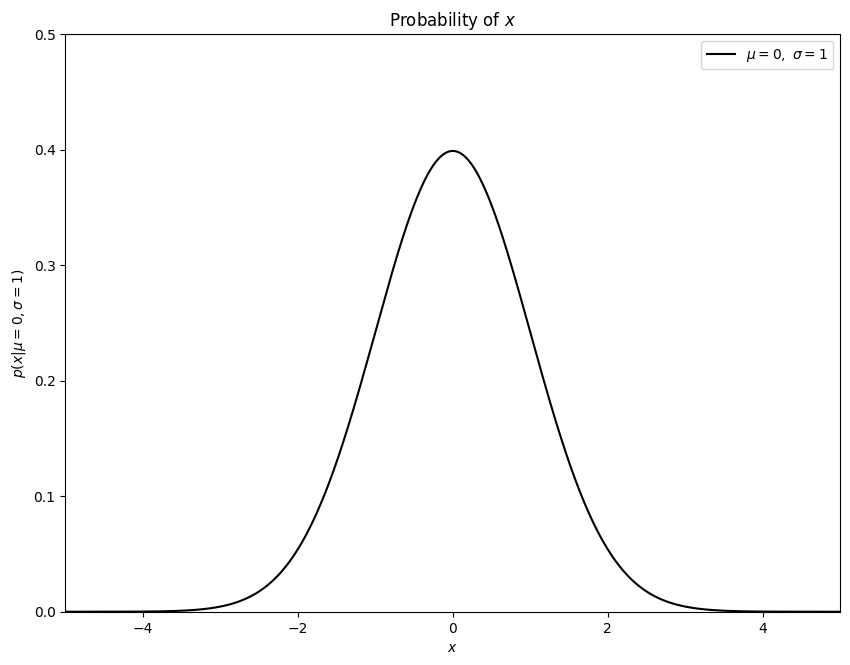

In [2]:
N = 10 # number of data points
true_mu = 1 # true mean
sigma = 0.2 # known standard deviation of each data point
data = norm(true_mu, sigma).rvs(N) # generate N random draws from a normal distribution with mean true_mu and stddev sigma
xgrid = np.linspace(-1,3,1000) # x grid for plotting

# Plot individual likelihoods
fig, ax = plt.subplots(figsize=(10, 7.5))
for i in range(N):
    likelihood_i = norm(data[i], sigma) # likelihood for data point i
    plt.plot(xgrid, likelihood_i.pdf(xgrid), label=f'Likelihood of $x_{i+1}$={data[i]:.2f}') # plot likelihood

# Plot combined likelihood
combined_likelihood = np.ones_like(xgrid) # ones_like array to hold combined likelihood

for i in range(N):
    likelihood_i = norm(data[i], sigma) # likelihood for data point i
    combined_likelihood *= likelihood_i.pdf(xgrid) # multiply likelihoods

plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Individual and Combined Likelihoods')
plt.legend()

fig, ax = plt.subplots(figsize=(10, 7.5))
plt.plot(xgrid, combined_likelihood/np.max(combined_likelihood), 'k-', lw=2, label='Combined Likelihood') # plot combined likelihood
plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Individual and Combined Likelihoods')
plt.legend()

# Find maximum likelihood estimate
mle_index = np.argmax(combined_likelihood)
mle_mu = xgrid[mle_index]
print(f'Maximum Likelihood Estimate of mu: {mle_mu:.4f}')
# Compare with analytical MLE
analytical_mle = np.mean(data)
print(f'Analytical MLE of mu (mean of data): {analytical_mle:.4f}')
plt.axvline(mle_mu, color='red', linestyle='--', label='MLE from Likelihood')
plt.axvline(analytical_mle, color='blue', linestyle='--', label='Analytical MLE')
plt.legend()

# Plot the distributions
fig, ax = plt.subplots(figsize=(10, 7.5))
dist = norm(0, 1)
x = np.linspace(-5, 5, 1000)
plt.plot(x, dist.pdf(x), c='black',label=r'$\mu=0,\ \sigma=1$')
plt.xlim(-5, 5)
plt.ylim(0, 0.5)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|\mu=0,\sigma=1)$')
plt.title('Probability of $x$')
plt.legend()
plt.show()

Fisher Matrix Error Estimate at MLE: 0.0632


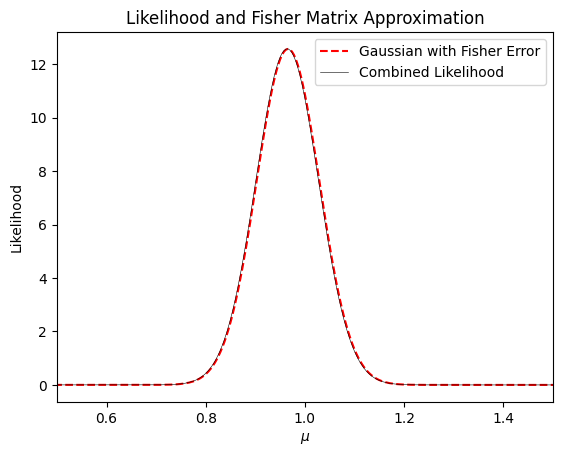

In [3]:
# Check the Fisher matrix error estimate makes sense: 
delta_theta = xgrid[1] - xgrid[0]  # spacing in theta grid to take derivatives

log_likelihood = np.log(combined_likelihood) # log-likelihood
second_derivative = np.diff(log_likelihood, n=2) / (delta_theta ** 2) # second derivative, we use np.diff twice to get the second derivative.

fisher_info = -second_derivative # Fisher information 
fisher_error = 1 / np.sqrt(fisher_info) # Fisher matrix error estimate is 1/sqrt{F}. This is correct only because we have a single parameter.

fisher_error_at_mle = fisher_error[mle_index - 1]  # -1 because np.diff reduces the array size by 2, recall that mle_index is for the original xgrid size
# Note that fisher_error has the same value for all points because the likelihood is Gaussian
print(f'Fisher Matrix Error Estimate at MLE: {fisher_error_at_mle:.4f}')

# Plot Gaussian with Fisher error
gaussian_fisher = norm(mle_mu, fisher_error_at_mle) # Gaussian centered at MLE with Fisher error
plt.plot(xgrid, gaussian_fisher.pdf(xgrid)/np.max(gaussian_fisher.pdf(xgrid)) * np.max(combined_likelihood), 
         'r--', label='Gaussian with Fisher Error') # plot Gaussian
plt.legend()
# Also show the original likelihood for comparison
plt.plot(xgrid, combined_likelihood, 'k-', lw=0.4, label='Combined Likelihood') # plot combined likelihood
plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Likelihood and Fisher Matrix Approximation')
plt.legend()
plt.xlim(0.5, 1.5)
plt.show()

This looks pretty good, we even managed to fix the normalization. 

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteroscedastic). Let's assume that each measurement has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$.

Maximum Likelihood Estimate of mu (Heteroscedastic): 0.9620


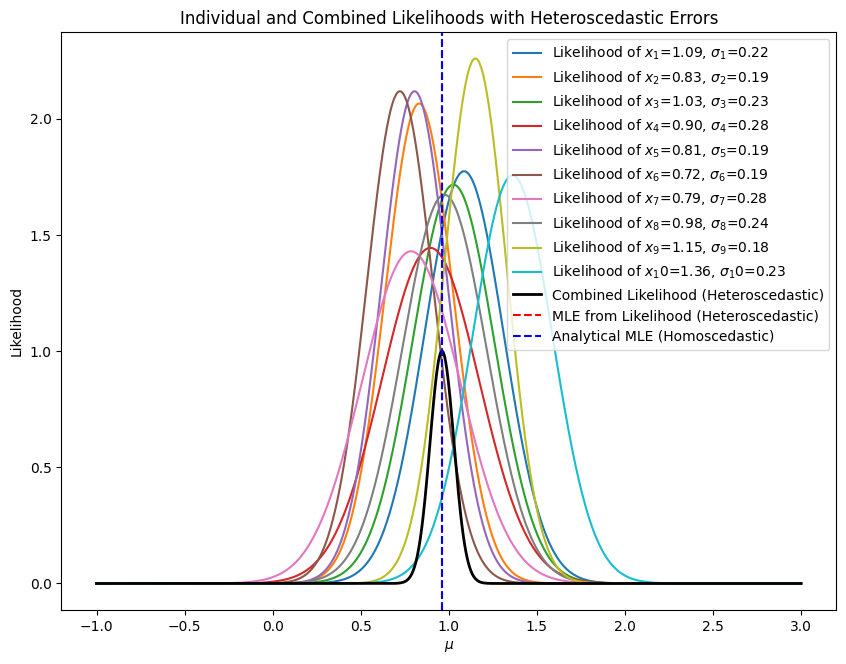

In [4]:
np.random.seed(42) # for reproducibility
sigma_values = norm(0.2, 0.05).rvs(N) # generate N random sigmas with mean 0.2 and stddev 0.05

# Plot individual likelihoods with heteroscedastic errors
fig, ax = plt.subplots(figsize=(10, 7.5))
for i in range(N):
    likelihood_i = norm(data[i], sigma_values[i]) # likelihood for data point i with its own sigma
    plt.plot(xgrid, likelihood_i.pdf(xgrid), label=rf'Likelihood of $x_{i+1}$={data[i]:.2f}, $\sigma_{i+1}$={sigma_values[i]:.2f}') # plot likelihood

# Plot combined likelihood
combined_likelihood_hetero = np.ones_like(xgrid) # ones_like array to hold combined likelihood
for i in range(N):
    likelihood_i = norm(data[i], sigma_values[i]) # likelihood for data point i with its own sigma
    combined_likelihood_hetero *= likelihood_i.pdf(xgrid) # multiply likelihoods
plt.plot(xgrid, combined_likelihood_hetero/np.max(combined_likelihood_hetero), 'k-', lw=2, label='Combined Likelihood (Heteroscedastic)') # plot combined likelihood
plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Individual and Combined Likelihoods with Heteroscedastic Errors')
plt.legend()

# Find maximum likelihood estimate for heteroscedastic case
mle_index_hetero = np.argmax(combined_likelihood_hetero)
mle_mu_hetero = xgrid[mle_index_hetero]
print(f'Maximum Likelihood Estimate of mu (Heteroscedastic): {mle_mu_hetero:.4f}')
plt.axvline(mle_mu_hetero, color='red', linestyle='--', label='MLE from Likelihood (Heteroscedastic)')
plt.axvline(analytical_mle, color='blue', linestyle='--', label='Analytical MLE (Homoscedastic)')
plt.legend()
plt.show()

Fisher Matrix Error Estimate at MLE (Heteroscedastic): 0.0680


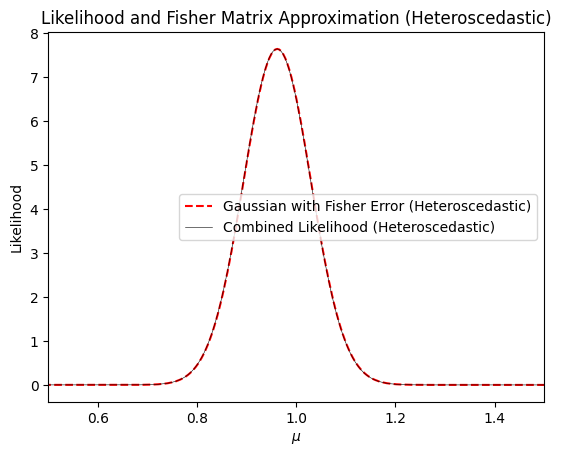

In [5]:
# Now we want to compare the fisher matrix error estimate in this heteroscedastic case
# Check the Fisher matrix error estimate makes sense:
delta_theta = xgrid[1] - xgrid[0] # spacing in theta grid to take derivatives
log_likelihood_hetero = np.log(combined_likelihood_hetero) # log-likelihood
second_derivative_hetero = np.diff(log_likelihood_hetero, n=2) / (delta_theta ** 2) # second derivative, we use np.diff twice to get the second derivative.
fisher_info_hetero = -second_derivative_hetero # Fisher information
fisher_error_hetero = 1 / np.sqrt(fisher_info_hetero) # Fisher matrix error estimate is 1/sqrt{F}. This is correct only because we have a single parameter.

fisher_error_at_mle_hetero = fisher_error_hetero[mle_index_hetero - 1] # -1 because np.diff reduces the array size by 2, recall that mle_index is for the original xgrid size

# note that fisher_error has the same value for all points because the likelihood is Gaussian?
print(f'Fisher Matrix Error Estimate at MLE (Heteroscedastic): {fisher_error_at_mle_hetero:.4f}')

# Plot Gaussian with Fisher error
gaussian_fisher_hetero = norm(mle_mu_hetero, fisher_error_at_mle_hetero) # Gaussian centered at MLE with Fisher error
plt.plot(xgrid, gaussian_fisher_hetero.pdf(xgrid)/np.max(gaussian_fisher_hetero.pdf(xgrid)) * np.max(combined_likelihood_hetero), 
         'r--', label='Gaussian with Fisher Error (Heteroscedastic)') # plot Gaussian
plt.legend()

# Also show the original likelihood for comparison
plt.plot(xgrid, combined_likelihood_hetero, 'k-', lw=0.4, label='Combined Likelihood (Heteroscedastic)') # plot combined likelihood
plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Likelihood and Fisher Matrix Approximation (Heteroscedastic)')
plt.legend()
plt.xlim(0.5, 1.5);
plt.show()